In [1]:
import numpy as np

vol_path = "/home/public/CTSpine1K/data/data-MHD_ctpro_woMask1/1.3.6.1.4.1.9328.50.4.0402/volume_gt.npy"
vol = np.load(vol_path)
print(vol.shape)

(512, 512, 512)


shape = (512, 512, 512)
dtype = float32

Data generation script shows: volume_gt.npy is stored as XYZ order.
axis0 -> X (left-right)
axis1 -> Y (posterior-anterior)
axis2 -> Z (inferior-superior / axial)

X / sagittal:
  full_index_range = 0:511
  slice_shape = (512, 512)
  min/max/mean = -113.419 / 2549.691 / 384.509
  nonzero_bbox_rows = 57:440
  nonzero_bbox_cols = 29:481

Y / coronal:
  full_index_range = 0:511
  slice_shape = (512, 512)
  min/max/mean = -64.515 / 3082.756 / 552.974
  nonzero_bbox_rows = 56:455
  nonzero_bbox_cols = 29:481

Z / axial:
  full_index_range = 0:511
  slice_shape = (512, 512)
  min/max/mean = -97.559 / 2719.589 / 234.695
  nonzero_bbox_rows = 56:455
  nonzero_bbox_cols = 57:422



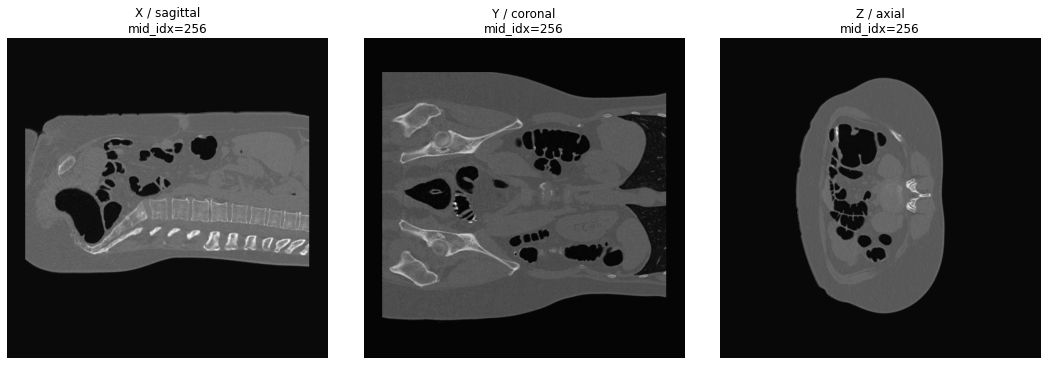

In [3]:
import numpy as np
import matplotlib.pyplot as plt

vol_path = "/home/public/CTSpine1K/data/data-MHD_ctpro_woMask1/1.3.6.1.4.1.9328.50.4.0402/volume_gt.npy"
vol = np.load(vol_path)
print('shape =', vol.shape)
print('dtype =', vol.dtype)
print()
print('Data generation script shows: volume_gt.npy is stored as XYZ order.')
print('axis0 -> X (left-right)')
print('axis1 -> Y (posterior-anterior)')
print('axis2 -> Z (inferior-superior / axial)')
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axis_info = [(0, 'X / sagittal'), (1, 'Y / coronal'), (2, 'Z / axial')]
for ax, (axis, title) in zip(axes, axis_info):
    idx = vol.shape[axis] // 2
    sl = np.take(vol, idx, axis=axis)
    ax.imshow(sl, cmap='gray')
    ax.set_title(f'{title}\nmid_idx={idx}')
    ax.axis('off')
    nz = np.argwhere(sl != 0)
    print(f'{title}:')
    print(f'  full_index_range = 0:{vol.shape[axis]-1}')
    print(f'  slice_shape = {sl.shape}')
    print(f'  min/max/mean = {sl.min():.3f} / {sl.max():.3f} / {sl.mean():.3f}')
    if nz.size:
        mins = nz.min(axis=0)
        maxs = nz.max(axis=0)
        print(f'  nonzero_bbox_rows = {mins[0]}:{maxs[0]}')
        print(f'  nonzero_bbox_cols = {mins[1]}:{maxs[1]}')
    else:
        print('  nonzero_bbox = None')
    print()

plt.tight_layout()
plt.show()


In [2]:
import os
import numpy as np
import SimpleITK as sitk

case_dir = "/home/public/CTSpine1K/data/data-MHD_ctpro_woMask1/volume-covid19-A-0382_ct/"

paths = {
    "ct_file.mha": os.path.join(case_dir, "ct_file.mha"),
    "vol_pred.npy": os.path.join(case_dir, "vol_pred.npy"),
    "volume_gt.npy": os.path.join(case_dir, "volume_gt.npy"),
}

def print_stats(name, arr):
    arr = np.asarray(arr)
    print(f"{name}:")
    print(f"  shape={arr.shape}, dtype={arr.dtype}")
    print(f"  min={float(arr.min()):.6f}, max={float(arr.max()):.6f}, mean={float(arr.mean()):.6f}")
    print()

for name, p in paths.items():
    if not os.path.exists(p):
        print(f"{name}: NOT FOUND -> {p}")
        print()
        continue

    if p.endswith(".mha"):
        img = sitk.ReadImage(p)
        arr_zyx = sitk.GetArrayFromImage(img)
        print_stats(name, arr_zyx)
    else:
        arr = np.load(p, mmap_mode="r")
        print_stats(name, arr)


ct_file.mha:
  shape=(305, 512, 512), dtype=float64
  min=-462.451348, max=2927.632592, mean=154.337329

vol_pred.npy:
  shape=(512, 512, 512), dtype=float32
  min=0.000000, max=8.087698, mean=0.031904

volume_gt.npy:
  shape=(512, 512, 512), dtype=float32
  min=0.000000, max=8.087698, mean=0.031904

volume_gt.npy:
  shape=(512, 512, 512), dtype=float32
  min=0.000000, max=0.975878, mean=0.030708

  min=0.000000, max=0.975878, mean=0.030708



In [ ]:
import os
import numpy as np

try:
    import SimpleITK as sitk
except Exception:
    sitk = None

case_dir = "/home/public/CTSpine1K/data/data-MHD_ctpro_woMask1/volume-covid19-A-0380_ct/"

paths = {
    "ct_file.mha": os.path.join(case_dir, "ct_file.mha"),
    "vol_pred.npy": os.path.join(case_dir, "vol_pred.npy"),
    "volume_gt.npy": os.path.join(case_dir, "volume_gt.npy"),
}


def print_stats(name, arr, fmt="{:.6f}"):
    a = np.asarray(arr)
    print(f"{name}:")
    print(f"  shape = {a.shape}")
    print(f"  dtype = {a.dtype}")
    print(f"  min  = {fmt.format(float(a.min()))}")
    print(f"  max  = {fmt.format(float(a.max()))}")
    print(f"  mean = {fmt.format(float(a.mean()))}")
    print(f"  std  = {fmt.format(float(a.std()))}")
    print("")

for name, p in paths.items():
    if not os.path.exists(p):
        print(f"{name}: NOT FOUND -> {p}\n")
        continue

    try:
        if p.endswith('.mha'):
            if sitk is None:
                print(f"{name}: SimpleITK not available, cannot read .mha -> {p}\n")
                continue
            img = sitk.ReadImage(p)
            arr_zyx = sitk.GetArrayFromImage(img)  # Z, Y, X order
            print_stats(name + " (ZYX order from SimpleITK)", arr_zyx)
        else:
            arr = np.load(p, mmap_mode='r')
            print_stats(name, arr)
    except Exception as e:
        print(f"{name}: ERROR reading {p}: {e}\n")


ct_file.mha (ZYX order from SimpleITK):
  shape = (305, 512, 512)
  dtype = float64
  min = -462.451348
  max = 2927.632592
  mean = 154.337329
  std = 366.339298

vol_pred.npy:
  shape = (512, 512, 512)
  dtype = float32
  min = 0.000000
  std = 366.339298

vol_pred.npy:
  shape = (512, 512, 512)
  dtype = float32
  min = 0.000000
  max = 8.087698
  mean = 0.031904
  max = 8.087698
  mean = 0.031904
  std = 0.087135

volume_gt.npy:
  shape = (512, 512, 512)
  dtype = float32
  min = 0.000000
  std = 0.087135

volume_gt.npy:
  shape = (512, 512, 512)
  dtype = float32
  min = 0.000000
  max = 0.975878
  mean = 0.030708
  max = 0.975878
  mean = 0.030708
  std = 0.097548

  std = 0.097548

